In [1]:
!pip install librosa

In [2]:
#import libraries
import os
import librosa
import numpy as np
import torch

In [3]:
#extracting mfccs
#
target_sr=16000
n_mfc=40
max_frames=128

"""Loads an audio file, extracts MFCCs, and pads/truncates to MAX_FRAMES."""
def extract_fixed_mfcc(file_path,augment=False):
    try:
        signal ,sr=librosa.load(file_path,sr=target_sr)
        # augmentation step(durign training)-layer 1- adding noise
        if augment:
            # Inject a small amount of random White Noise (50% chance)
            if random.random() < 0.5:
                noise_amp = 0.001 * np.random.uniform() * np.amax(signal)
                signal = signal + noise_amp * np.random.normal(size=signal.shape)
        
        
        mfcc = librosa.feature.mfcc(y=signal,sr=sr,n_mfcc=n_mfc,norm='ortho',lifter=80)

        #22 is considered the ideal lifter value for speech recognition tasks.
        num_rows,num_cols=mfcc.shape
        #slicieng and padding the audio clip for matrix consistency
        if num_cols>max_frames :
            mfcc_fixed=mfcc[:,:max_frames]
        else:
            pad_width=max_frames-num_cols
            mfcc_fixed=np.pad(mfcc,((0,0),(0,pad_width)),mode='constant')
            #0 rows to the top and bottom 0 columns to the left and  columns to the right
        #layer2 - specaugment-on mfcc matrix
        if augment:
            # Frequency Masking (Zero out random horizontal bands of coefficients)
            if random.random() < 0.5:
                # Mask up to 6 consecutive frequency bins
                f_mask_width = random.randint(1, 3)
                f_low = random.randint(0, n_mfc - f_mask_width)
                mfcc_fixed[f_low : f_low + f_mask_width, :] = 0.0

            # Time Masking (Zero out random vertical bands of time frames)
            if random.random() < 0.5:
                # Mask up to 15 consecutive time frames
                t_mask_width = random.randint(1, 8)
                t_low = random.randint(0, max_frames - t_mask_width)
                mfcc_fixed[:, t_low : t_low + t_mask_width] = 0.0
        return mfcc_fixed
    except Exception as e:
        print(f"Error processing {file_path}:{e}")
        

In [4]:
#the tess dataset only consists of female voices so we must use both tess and ravdess dataset

import random
from collections import defaultdict
tess_dir='/kaggle/input/datasets/ejlok1/toronto-emotional-speech-set-tess/TESS Toronto emotional speech set data'
ravdess_dir='/kaggle/input/datasets/uwrfkaggler/ravdess-emotional-speech-audio'
emotion_map={
    "happy":0,
    "sad":1,
    "angry":2,
    "neutral":3
}
#the ravdess and tess datasets should give same labels for each emotions(0,1,2,3)
ravdess_emotion_map={
    "01":3,#neutral
    "03":0,#happy
    "04":1,#sad
    "05":2#angry
}

tess_files = defaultdict(list)
#default-dict- automatically initializing a default value if the key is missing.
ravdess_files = defaultdict(list)

# 1. Collect TESS paths
for root, dirs, files in os.walk(tess_dir):
    for filename in files:
        if filename.endswith(".wav"):
            filepath = os.path.join(root, filename)
            for emotion, emotion_id in emotion_map.items():
                if emotion in filename.lower() or emotion in filepath.lower():
                    tess_files[emotion_id].append(filepath)
                    break

# 2. Collect RAVDESS paths
for root, dirs, files in os.walk(ravdess_dir):
    for filename in files:
        if filename.endswith(".wav"):
            parts = filename.split('-')
            if len(parts) >= 3:
                emotion_code = parts[2]
                if emotion_code in ravdess_emotion_map:
                    emotion_id = ravdess_emotion_map[emotion_code]
                    filepath = os.path.join(root, filename)
                    ravdess_files[emotion_id].append(filepath)

In [5]:
#the tess+ravdess datset is quite large so we need to take only some of the samples
max_files_per_emotion = 96 # 96 is optimal because neutral in ravdess has only 96 files 

sampled_paths_with_labels = []

# Seed the random generator for consistent samples across runs
random.seed(42)

for emotion_id in emotion_map.values():
    # Sample from TESS
    tess_pool = tess_files[emotion_id]
    sample_size_tess = min(max_files_per_emotion, len(tess_pool))
    sampled_tess = random.sample(tess_pool, sample_size_tess)
    for path in sampled_tess:
        sampled_paths_with_labels.append((path, emotion_id))
        
    # Sample from RAVDESS
    ravdess_pool = ravdess_files[emotion_id]
    sample_size_ravdess = min(max_files_per_emotion, len(ravdess_pool))
    sampled_ravdess = random.sample(ravdess_pool, sample_size_ravdess)
    for path in sampled_ravdess:
        sampled_paths_with_labels.append((path, emotion_id))

# Shuffle the final collection so TESS and RAVDESS files are intermixed
random.shuffle(sampled_paths_with_labels)

print(f"Total files selected for processing: {len(sampled_paths_with_labels)}")

Total files selected for processing: 768


In [6]:
#extract mfcc features from the datset
random.seed(42)
random.shuffle(sampled_paths_with_labels)
total_files = len(sampled_paths_with_labels)
train_end = int(0.70 * total_files)  # 70% for training
val_end = train_end + int(0.15 * total_files)

train_paths = sampled_paths_with_labels[:train_end]
val_paths = sampled_paths_with_labels[train_end:val_end]
test_paths = sampled_paths_with_labels[val_end:]
x_train, y_train = [], []
x_val, y_val = [], []
x_test, y_test = [], []

for filepath, emotion_id in train_paths:
    mfcc_fea = extract_fixed_mfcc(filepath, augment=True)
    if mfcc_fea is not None:
        x_train.append(mfcc_fea)
        y_train.append(emotion_id)

#(no augmentation)
for filepath, emotion_id in val_paths:
    mfcc_fea = extract_fixed_mfcc(filepath, augment=False)
    if mfcc_fea is not None:
        x_val.append(mfcc_fea)
        y_val.append(emotion_id)

for filepath, emotion_id in test_paths:
    mfcc_fea = extract_fixed_mfcc(filepath, augment=False)
    if mfcc_fea is not None:
        x_test.append(mfcc_fea)
        y_test.append(emotion_id)

# 3. Convert all arrays to NumPy format
x_data_train = np.array(x_train, dtype=np.float32)
y_data_train = np.array(y_train, dtype=np.int64)

x_data_val = np.array(x_val, dtype=np.float32)
y_data_val = np.array(y_val, dtype=np.int64)

x_data_test = np.array(x_test, dtype=np.float32)
y_data_test = np.array(y_test, dtype=np.int64)

# 4. Diagnostics printout
print(f"Train Features: {x_data_train.shape} | Train Labels: {y_data_train.shape}")
print(f"Val Features:   {x_data_val.shape}   | Val Labels:   {y_data_val.shape}")
print(f"Test Features:  {x_data_test.shape}  | Test Labels:  {y_data_test.shape}")
        

Train Features: (537, 40, 128) | Train Labels: (537,)
Val Features:   (115, 40, 128)   | Val Labels:   (115,)
Test Features:  (116, 40, 128)  | Test Labels:  (116,)


In [7]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

def compare_mfccs(mfcc1, mfcc2):
    mad = np.mean(np.abs(mfcc1 - mfcc2))

    cos = cosine_similarity(
        mfcc1.flatten().reshape(1, -1),
        mfcc2.flatten().reshape(1, -1)
    )[0, 0]

   

    return mad, cos

a=22
b=80
for filepath, emotion_id in test_paths:
    signal ,sr=librosa.load(filepath,sr=target_sr)
    mfcc_a = librosa.feature.mfcc(y=signal,sr=sr,n_mfcc=n_mfc,norm='ortho',lifter=a)
    mfcc_b = librosa.feature.mfcc(y=signal,sr=sr,n_mfcc=n_mfc,norm='ortho',lifter=b)
   
    mad,cos = compare_mfccs(mfcc_a,mfcc_b)
    print(f'MAD : {mad} and COS: {cos}')
        
    




    

MAD : 307.40411376953125 and COS: 0.12262149900197983
MAD : 133.0871124267578 and COS: 0.5193572044372559
MAD : 306.6741638183594 and COS: 0.10363394021987915
MAD : 253.31861877441406 and COS: 0.19956500828266144
MAD : 106.14796447753906 and COS: 0.886249303817749
MAD : 219.22244262695312 and COS: 0.2655268907546997
MAD : 135.63145446777344 and COS: 0.6599953174591064
MAD : 115.0036849975586 and COS: 0.7071067094802856
MAD : 294.67828369140625 and COS: -0.08380070328712463
MAD : 240.19915771484375 and COS: 0.3448273241519928
MAD : 196.3652801513672 and COS: 0.3825627267360687
MAD : 212.60366821289062 and COS: 0.3006780743598938
MAD : 132.43809509277344 and COS: 0.6835798025131226
MAD : 308.14227294921875 and COS: 0.25154927372932434
MAD : 316.9266662597656 and COS: 0.0029343978967517614
MAD : 248.8361053466797 and COS: 0.14668986201286316
MAD : 248.1478271484375 and COS: 0.30364206433296204
MAD : 332.7756042480469 and COS: -0.11381858587265015
MAD : 263.16290283203125 and COS: 0.256124

In [8]:
import numpy as np
from sklearn.decomposition import PCA

import numpy as np

def fisher_discriminant_ratio(X, y):
    """
    X : ndarray of shape (n_samples, n_features)
    y : ndarray of shape (n_samples,)
    """

    classes = np.unique(y)

    overall_mean = np.mean(X, axis=0)

    SB = 0.0   # Between-class scatter
    SW = 0.0   # Within-class scatter

    for c in classes:

        Xc = X[y == c]

        class_mean = np.mean(Xc, axis=0)

        # Between-class scatter
        SB += len(Xc) * np.sum((class_mean - overall_mean) ** 2)

        # Within-class scatter
        SW += np.sum((Xc - class_mean) ** 2)

    fdr = SB / (SW + 1e-12)

    return fdr, SB, SW

a = 22
b = 2000000
max_frames=128
x_a, y_a = [], []
x_b, y_b = [], []
for filepath, emotion_id in test_paths:#since test data is unaugmented
    signal ,sr=librosa.load(filepath,sr=target_sr)
    mfcc_a = librosa.feature.mfcc(y=signal,sr=sr,n_mfcc=n_mfc,norm='ortho',lifter=a)
    mfcc_b = librosa.feature.mfcc(y=signal,sr=sr,n_mfcc=n_mfc,norm='ortho',lifter=b)
    num_rows,num_cols=mfcc_a.shape
        #slicieng and padding the audio clip for matrix consistency
    if num_cols>max_frames :
        mfcc_a=mfcc_a[:,:max_frames]
    else:
        pad_width=max_frames-num_cols
        mfcc_a=np.pad(mfcc_a,((0,0),(0,pad_width)),mode='constant')

    num_rows,num_cols=mfcc_b.shape
        #slicieng and padding the audio clip for matrix consistency
    if num_cols>max_frames :
        mfcc_b=mfcc_b[:,:max_frames]
    else:
        pad_width=max_frames-num_cols
        mfcc_b=np.pad(mfcc_b,((0,0),(0,pad_width)),mode='constant')
 
    if mfcc_a is not None:
        x_a.append(mfcc_a.flatten())
        y_a.append(emotion_id)    
    if mfcc_b is not None:
        x_b.append(mfcc_b.flatten())
        y_b.append(emotion_id)    


#for i, x in enumerate(x_a):
 #   if len(x) != len(x_a[0]):
  #      print(i, len(x))




x_a = np.array(x_a)
y_a = np.array(y_a)

x_b = np.array(x_b)
y_b = np.array(y_b)        
print("x_a shape:", x_a.shape)
print("y_a shape:", y_a.shape)
print("x_b shape:", x_b.shape)
print("y_b shape:", y_b.shape)

fdr22, SB22, SW22 = fisher_discriminant_ratio(x_a, y_a)
fdr25, SB25, SW25 = fisher_discriminant_ratio(x_b, y_b)

print(f"Lifter {a}")
print(f"Between-class scatter : {SB22:.4f}")
print(f"Within-class scatter  : {SW22:.4f}")
print(f"FDR                  : {fdr22:.6f}")

print()

print(f"Lifter {b}")
print(f"Between-class scatter : {SB25:.4f}")
print(f"Within-class scatter  : {SW25:.4f}")
print(f"FDR                  : {fdr25:.6f}")    

x_a shape: (116, 5120)
y_a shape: (116,)
x_b shape: (116, 5120)
y_b shape: (116,)
Lifter 22
Between-class scatter : 930522240.0000
Within-class scatter  : 11040613376.0000
FDR                  : 0.084282

Lifter 2000000
Between-class scatter : 8490773504.0000
Within-class scatter  : 74269114368.0000
FDR                  : 0.114324


In [9]:
#make a custom dataset
import torch 
from torch.utils.data import Dataset,random_split,DataLoader,RandomSampler

#WHY ARE WE USING A CUSTOM DATASET--->
# 1. INFINITE DYNAMIC VARIETY: 
#    Instead of applying static augmentations once upfront, this method 
#    regenerates random noise and SpecAugment masks at every single epoch. 
#    The model almost never sees the exact same feature matrix twice, 
#    effectively multiplying our training data volume to crush overfitting.
#
# 2. OPTIMAL MEMORY EFFICIENCY: 
#    Keeps RAM usage completely flat. Instead of loading thousands of 
#    dense 2D MFCC matrices into system memory at once, we only store 
#    lightweight file paths and process audio clips dynamically batch-by-batch.

class Finalcustomdataset(Dataset):
    def __init__(self,features,labels):
        self.features=torch.tensor(features,dtype=torch.float32)
        self.labels=torch.tensor(labels,dtype=torch.long)
    
        #torch.long=int64
        #int64 is optimal as PyTorch's library is hardcoded for int64 and nn.crossentopy 
        #loss works best for int64
        
        

    def __len__(self):
        return len(self.labels)

    def __getitem__(self,idx):
        x=self.features[idx] # Shape: (20, 128)
        y=self.labels[idx] 
        x=x.unsqueeze(0)   # Shape becomes: (1, 20, 128) -> Ready for 2D CNN
        return x,y


#instantiating the dataset
train_dataset = Finalcustomdataset(x_data_train,y_data_train)
test_dataset = Finalcustomdataset(x_data_test,y_data_test)
val_dataset = Finalcustomdataset(x_data_val,y_data_val)


train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(test_dataset, batch_size=32,  shuffle=False)
test_loader=DataLoader(test_dataset,batch_size=32, shuffle=False)




In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class emotionCNN(nn.Module):

    def __init__(self, num_classes):
        super().__init__()

        # Block 1
        self.conv1 = nn.Conv2d(
            1, 16,
            kernel_size=3,
            padding=1,
            dilation=(1,2)
        )
        self.bn1 = nn.BatchNorm2d(16)
        self.pool1 = nn.MaxPool2d(2, 2, ceil_mode=True)
        self.drop1 = nn.Dropout2d(0.10)

        # Block 2
        self.conv2 = nn.Conv2d(
            16, 32,
            kernel_size=3,
            padding=1,
            dilation=(1,4)
        )
        self.bn2 = nn.BatchNorm2d(32)
        self.pool2 = nn.MaxPool2d(2, 2, ceil_mode=True)
        self.drop2 = nn.Dropout2d(0.20)

        # Block 3
        self.conv3 = nn.Conv2d(
            32, 64,
            kernel_size=3,
            padding=1
        )
        self.bn3 = nn.BatchNorm2d(64)
        self.drop3 = nn.Dropout2d(0.30)

        # Block 4
        self.conv4 = nn.Conv2d(
            64, 64,
            kernel_size=3,
            padding=1
        )
        self.bn4 = nn.BatchNorm2d(64)
        self.drop4 = nn.Dropout2d(0.30)

        self.adaptive_pool = nn.AdaptiveAvgPool2d((4,4))

        self.fc = nn.Linear(64 * 4 * 4, num_classes)

    def forward(self, x):

        x = self.drop1(
                self.pool1(
                    F.elu(self.bn1(self.conv1(x)))
                )
            )

        x = self.drop2(
                self.pool2(
                    F.elu(self.bn2(self.conv2(x)))
                )
            )

        x = self.drop3(
                F.elu(self.bn3(self.conv3(x)))
            )

        x = self.drop4(
                F.elu(self.bn4(self.conv4(x)))
            )

        x = self.adaptive_pool(x)

        x = torch.flatten(x, 1)

        x = self.fc(x)

        return x

In [11]:


num_epochs = 125
# Initialize device, model, loss, and optimizer
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = emotionCNN(num_classes=4).to(device) 
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001,weight_decay=1e-4,eps=1e-8)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=0.5, 
    patience=7, 
    
)

best_val_loss = float('inf')
best_val_acc = 0.0


for epoch in range(num_epochs):
    # --- TRAINING PHASE ---
    model.train()
    running_train_loss = 0.0
    running_train_correct = 0  # Track correct predictions for training
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        #to prevent gradient addition of previous batches
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_train_loss += loss.item() * inputs.size(0)
        
        # Calculate training accuracy metrics
        #to see along dim 1(hori) for max logit
        _, preds = torch.max(outputs, 1)  # Get the index of the highest logit
        running_train_correct += torch.sum(preds == labels.data).item()
        
    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    epoch_train_acc = running_train_correct / len(train_loader.dataset)* 100
    
    # --- VALIDATION PHASE ---
    model.eval()
    running_val_loss = 0.0
    running_val_correct = 0  # Track correct predictions for validation
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            running_val_loss += loss.item() * inputs.size(0)
            
            # Calculate validation accuracy metrics
            _, preds = torch.max(outputs, 1)
            running_val_correct += torch.sum(preds == labels.data).item()
            
    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    epoch_val_acc = (running_val_correct / len(val_loader.dataset)) * 100
    scheduler.step(epoch_val_loss)
    
    # --- MONITOR PERFORMANCE AND OVERFITTING ---
    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"  Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.2f}%")
    print(f"  Val Loss:   {epoch_val_loss:.4f} | Val Acc:   {epoch_val_acc:.2f}%")
    
    
    print("-" * 50)
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        best_val_acc = epoch_val_acc
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': best_val_loss,
            'val_acc': best_val_acc,
        }, 'best_model.pth')
        print(f"    ✓ Best model saved (Val Loss: {best_val_loss:.4f}, Val Acc: {best_val_acc:.2f}%)")









Epoch [1/125]
  Train Loss: 1.2328 | Train Acc: 44.88%
  Val Loss:   1.0265 | Val Acc:   62.93%
--------------------------------------------------
    ✓ Best model saved (Val Loss: 1.0265, Val Acc: 62.93%)
Epoch [2/125]
  Train Loss: 1.0223 | Train Acc: 64.99%
  Val Loss:   0.8671 | Val Acc:   78.45%
--------------------------------------------------
    ✓ Best model saved (Val Loss: 0.8671, Val Acc: 78.45%)
Epoch [3/125]
  Train Loss: 0.9498 | Train Acc: 66.67%
  Val Loss:   0.8081 | Val Acc:   78.45%
--------------------------------------------------
    ✓ Best model saved (Val Loss: 0.8081, Val Acc: 78.45%)
Epoch [4/125]
  Train Loss: 0.9314 | Train Acc: 67.04%
  Val Loss:   0.7848 | Val Acc:   80.17%
--------------------------------------------------
    ✓ Best model saved (Val Loss: 0.7848, Val Acc: 80.17%)
Epoch [5/125]
  Train Loss: 0.8625 | Train Acc: 72.44%
  Val Loss:   0.7506 | Val Acc:   77.59%
--------------------------------------------------
    ✓ Best model saved (Val L

In [12]:

def evaluate_test_accuracy(model, test_loader, weights_path='best_model.pth'):
    """
    Loads the best trained weights and calculates final test accuracy.
    """
    # 1. Load the best saved weights
    try:
        checkpoint = torch.load(weights_path, map_location=device)
        model.load_state_dict(checkpoint['model_state_dict'])  # ✅ extract the right key
        print(f"\nSuccessfully loaded best model weights from '{weights_path}'")
    except FileNotFoundError:
        print(f"\nWarning: '{weights_path}' not found. Evaluating current model weights instead.")
    # 2. Set model to evaluation mode
    model.eval()
    
    correct = 0
    total = 0
    
    # Disable gradient tracking for testing
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            # Forward pass to get predictions
            outputs = model(inputs)
            
            # Get the predicted class index
            _, predicted = torch.max(outputs, 1)
            
            # Track counts
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
    # 3. Calculate and display final accuracy
    test_accuracy = (correct / total) * 100
    return test_accuracy
test_accuracy=evaluate_test_accuracy(model,test_loader)    
print("-" * 50)
print(f" FINAL TEST ACCURACY: {test_accuracy:.2f}%")

print("-" * 50)
    
   


Successfully loaded best model weights from 'best_model.pth'
--------------------------------------------------
 FINAL TEST ACCURACY: 93.10%
--------------------------------------------------


Successfully loaded weights from 'best_model.pth' for evaluation.


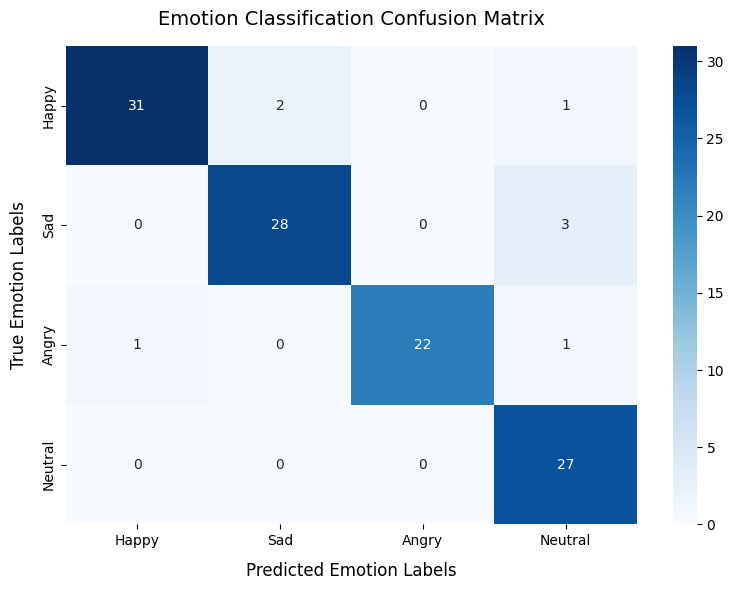


 DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

       Happy       0.97      0.91      0.94        34
         Sad       0.93      0.90      0.92        31
       Angry       1.00      0.92      0.96        24
     Neutral       0.84      1.00      0.92        27

    accuracy                           0.93       116
   macro avg       0.94      0.93      0.93       116
weighted avg       0.94      0.93      0.93       116



In [13]:
import torch
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

def plot_confusion_matrix(model, test_loader, weights_path='best_model.pth'):
    # 1. Define your exact emotion labels in order
    emotion_labels = ["Happy", "Sad", "Angry", "Neutral"]
    
    # 2. Load the best saved weights
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    try:
        checkpoint = torch.load(weights_path, map_location=device)
        model.load_state_dict(checkpoint['model_state_dict'])
        print(f"Successfully loaded weights from '{weights_path}' for evaluation.")
    except FileNotFoundError:
        print(f"Warning: '{weights_path}' not found. Using current weights.")
        
    model.eval()
    
    all_preds = []
    all_labels = []
    
    # 3. Gather predictions across the entire test set
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            # Move to CPU and convert to numpy array lists
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    # 4. Compute the mathematical confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    
    # 5. Plot the matrix using Seaborn
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm, 
        annot=True,          # Put the numbers inside the squares
        fmt='d',             # Format numbers as integers
        cmap='Blues',        # Beautiful blue gradient color scheme
        xticklabels=emotion_labels, 
        yticklabels=emotion_labels
    )
    
    plt.title('Emotion Classification Confusion Matrix', fontsize=14, pad=15)
    plt.xlabel('Predicted Emotion Labels', fontsize=12, labelpad=10)
    plt.ylabel('True Emotion Labels', fontsize=12, labelpad=10)
    plt.tight_layout()
    plt.show()
    
    # 6. Print out a comprehensive classification report (Precision, Recall, F1-Score)
    print("\n" + "="*60)
    print(" DETAILED CLASSIFICATION REPORT")
    print("="*60)
    print(classification_report(all_labels, all_preds, target_names=emotion_labels))
    print("="*60)

# --- EXECUTE THE PLOT ---
# Pass your initialized model architecture and the test_loader
plot_confusion_matrix(model, test_loader)